In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [3]:
# TotalCharges is stored as string so we convert it to number
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows where TotalCharges is null
df.dropna(subset=['TotalCharges'], inplace=True)

# Drop customerID as it is not useful for prediction
df.drop(columns=['customerID'], inplace=True)

# Convert target column: Yes → 1, No → 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Churn distribution:")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True))  # it shows % split

Churn distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


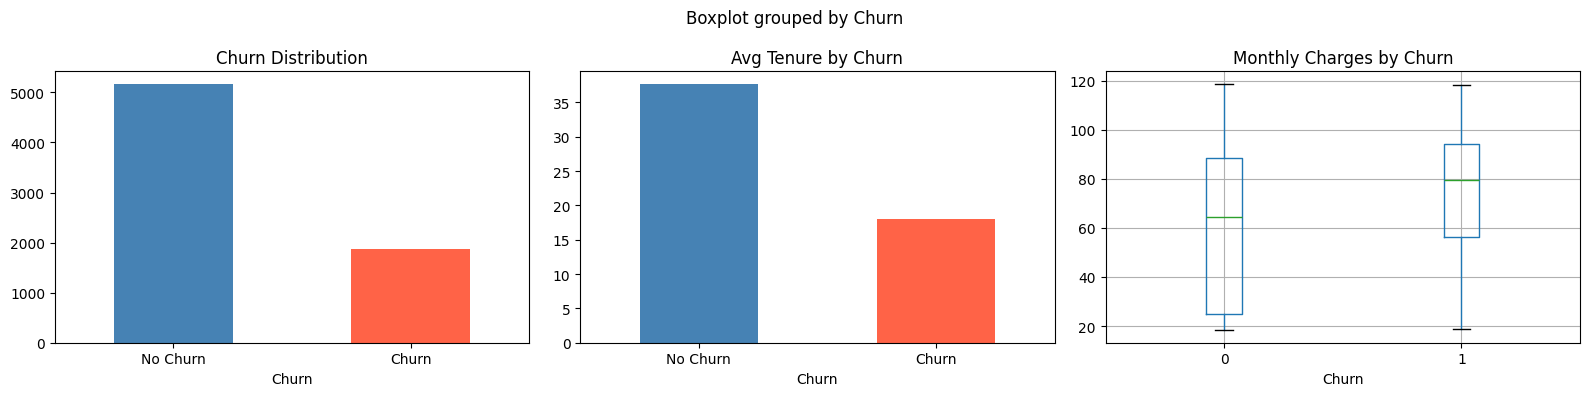

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Churn distribution
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'])
axes[0].set_title('Churn Distribution')
axes[0].set_xticklabels(['No Churn', 'Churn'], rotation=0)

# Plot 2: Tenure vs Churn
df.groupby('Churn')['tenure'].mean().plot(kind='bar', ax=axes[1], color=['steelblue','tomato'])
axes[1].set_title('Avg Tenure by Churn')
axes[1].set_xticklabels(['No Churn', 'Churn'], rotation=0)

# Plot 3: Monthly Charges vs Churn
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[2])
axes[2].set_title('Monthly Charges by Churn')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()

In [5]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_model = df.copy()

# Encode binary columns (Yes/No → 1/0)
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in binary_cols:
    df_model[col] = df_model[col].map({'Yes': 1, 'No': 0,
                                        'No phone service': 0,
                                        'No internet service': 0})

# Encode multi-category columns
le = LabelEncoder()
df_model['gender'] = le.fit_transform(df_model['gender'])
df_model['InternetService'] = le.fit_transform(df_model['InternetService'])
df_model['Contract'] = le.fit_transform(df_model['Contract'])
df_model['PaymentMethod'] = le.fit_transform(df_model['PaymentMethod'])

# Split features and target
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

# Scale numeric columns
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X[num_cols] = scaler.fit_transform(X[num_cols])

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7032, 19)
Target shape: (7032,)


In [6]:

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Split BEFORE applying SMOTE (as we never apply SMOTE to test data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# we Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_sm).value_counts().to_dict())

Before SMOTE: {0: 4130, 1: 1495}
After SMOTE: {0: 4130, 1: 4130}


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost":             XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)

    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
    print(f"  AUC Score: {auc:.4f}")

    results[name] = {'model': model, 'auc': auc, 'y_proba': y_proba}


  Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.89      0.74      0.81      1033
       Churn       0.51      0.75      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.74      0.75      1407

  AUC Score: 0.8229

  Random Forest
              precision    recall  f1-score   support

    No Churn       0.86      0.81      0.83      1033
       Churn       0.55      0.64      0.59       374

    accuracy                           0.76      1407
   macro avg       0.71      0.72      0.71      1407
weighted avg       0.78      0.76      0.77      1407

  AUC Score: 0.8131


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:21:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



  XGBoost
              precision    recall  f1-score   support

    No Churn       0.87      0.80      0.83      1033
       Churn       0.54      0.66      0.59       374

    accuracy                           0.76      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.76      0.77      1407

  AUC Score: 0.8041


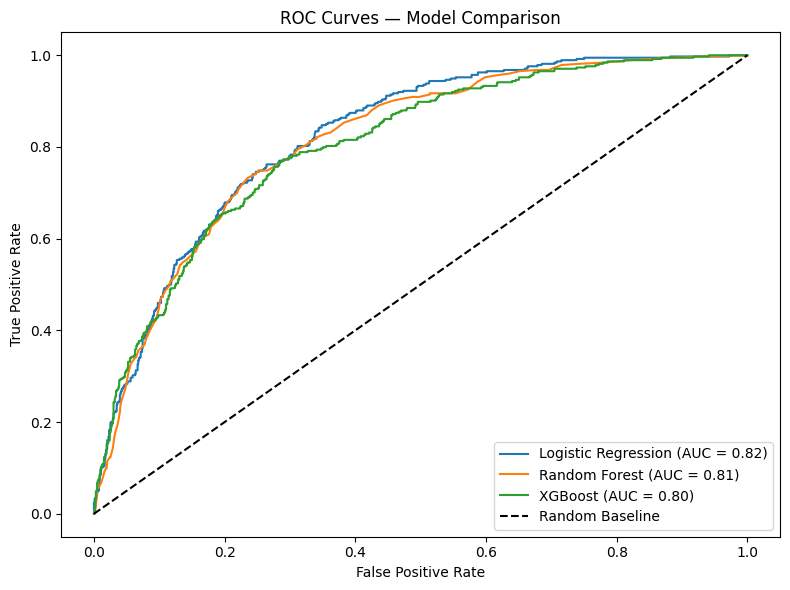

In [8]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['auc']:.2f})")

plt.plot([0,1], [0,1], 'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

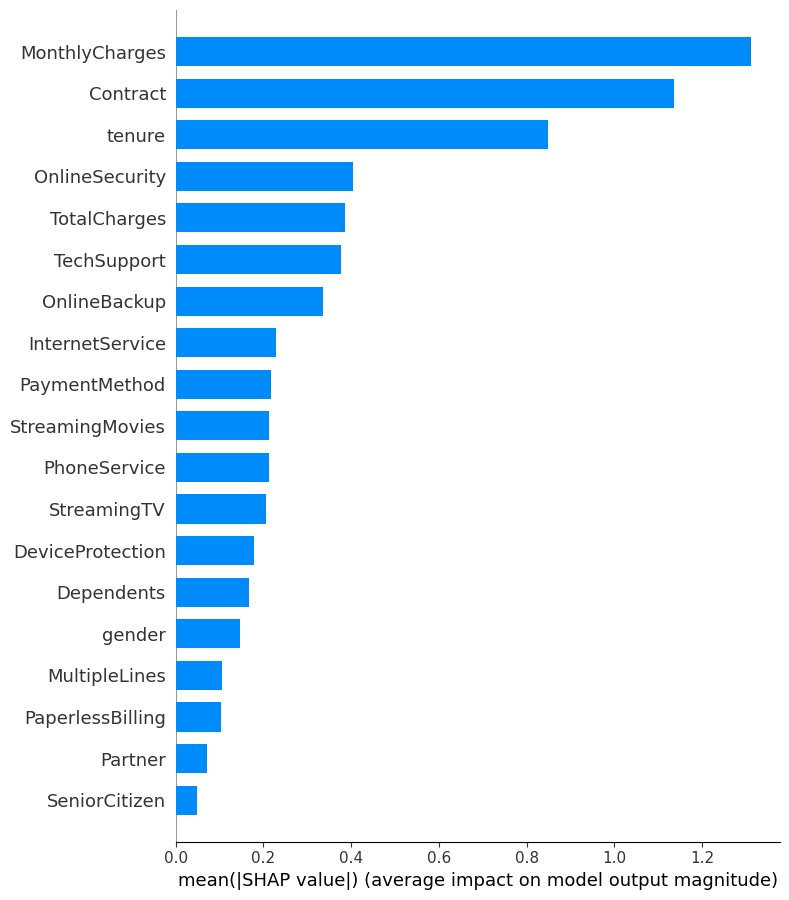

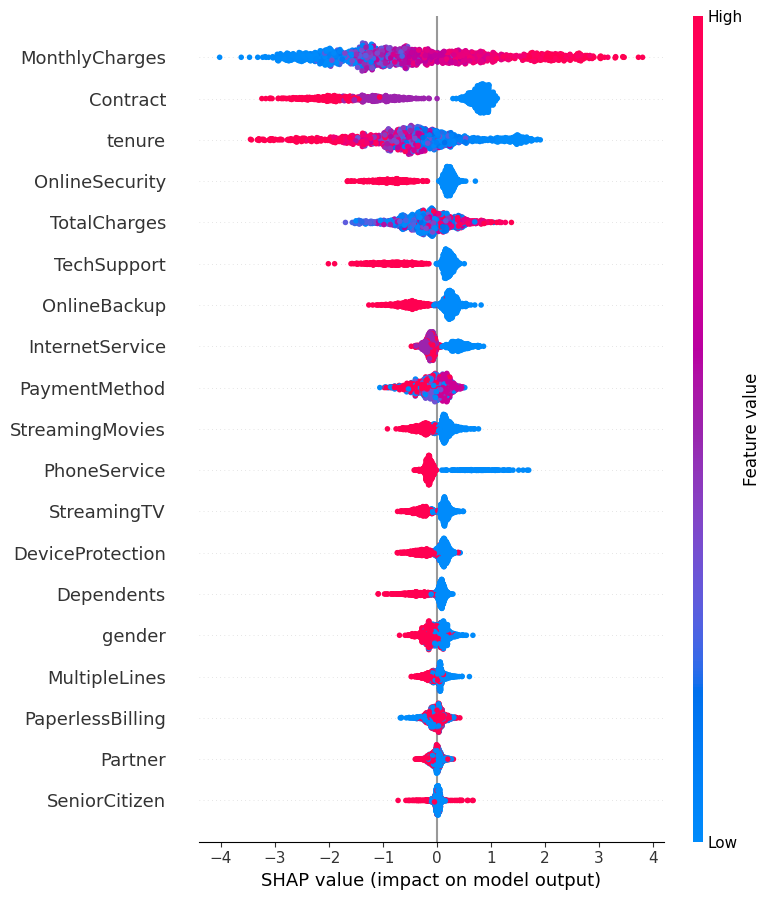

In [9]:
import shap

# We Use the XGBoost model as SHAP works best with tree models
best_model = results['XGBoost']['model']

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Plot 1: Feature importance summary
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150)
plt.show()

# Plot 2: Detailed impact plot
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('shap_detail.png', dpi=150)
plt.show()

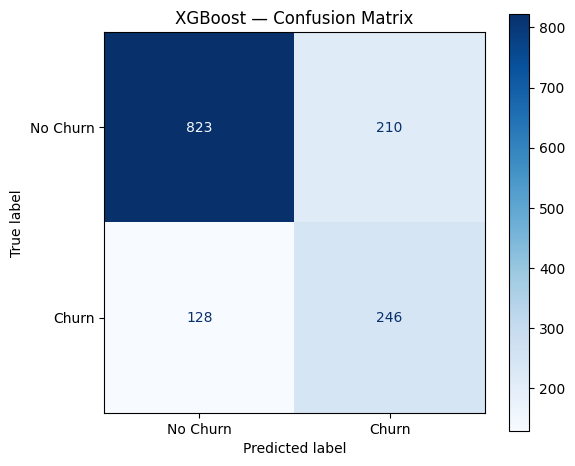

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

best_preds = results['XGBoost']['model'].predict(X_test)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, best_preds,
    display_labels=['No Churn', 'Churn'],
    cmap='Blues', ax=ax
)
ax.set_title('XGBoost — Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [11]:
print("\n FINAL MODEL COMPARISON")
print("-" * 40)
for name, res in results.items():
    print(f"{name:25s}  AUC: {res['auc']:.4f}")


 FINAL MODEL COMPARISON
----------------------------------------
Logistic Regression        AUC: 0.8229
Random Forest              AUC: 0.8131
XGBoost                    AUC: 0.8041


In [12]:
import zipfile
import os

# Create a zip with all your output files
with zipfile.ZipFile('churn_project.zip', 'w') as zipf:
    files = [
        'eda_plots.png',
        'roc_curves.png',
        'shap_importance.png',
        'shap_detail.png',
        'confusion_matrix.png',
        'WA_Fn-UseC_-Telco-Customer-Churn.csv'
    ]
    for f in files:
        if os.path.exists(f):
            zipf.write(f)
            print(f"Added: {f}")
        else:
            print(f"NOT FOUND: {f}")

print("\nDone! Download churn_project.zip from the files panel")

Added: eda_plots.png
Added: roc_curves.png
Added: shap_importance.png
Added: shap_detail.png
Added: confusion_matrix.png
Added: WA_Fn-UseC_-Telco-Customer-Churn.csv

Done! Download churn_project.zip from the files panel
